<a href="https://colab.research.google.com/github/Decoding-Data-Science/CommunityWorkshops/blob/main/Copy_of_simple_langchain_create_agent_duckduckgo_weather_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple LangChain `create_agent` with Search Tool

This is the beginner-friendly version.

## Goal

Build a simple LangChain agent that can answer current questions like:

> What is the weather in the UAE today?

## Why this version is simpler

- No Serper API key
- No custom API function
- No manual JSON parsing
- Only OpenAI key is needed
- Uses DuckDuckGo search through LangChain Community


## Step 1: Install Libraries

Run this first. If Colab asks to restart the runtime, restart and continue.


In [1]:
!pip -q install -U langchain langchain-openai langchain-community duckduckgo-search ddgs


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.1/113.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.8/173.8 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 114.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2

## Step 2: Add OpenAI API Key in Colab Secrets

In Google Colab:

1. Click the **key icon** on the left sidebar.
2. Add this secret exactly:

```text
OPENAI_API_KEY
```

3. Enable **Notebook access**.

No other API key is needed for this simple version.


In [2]:
import openai
import os
from google.colab import userdata

# Retrieve the OpenAI API key from Google Colab secrets
openai.api_key = userdata.get('openai')

os.environ["OPENAI_API_KEY"] = openai.api_key

print("OpenAI API key loaded successfully.")

OpenAI API key loaded successfully.


## Step 3: Import `create_agent` and DuckDuckGo Search Tool

This is the key simplification.

Instead of creating your own Serper function, use LangChain's built-in community search tool:

```python
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()
```


In [3]:
from langchain.agents import create_agent
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

print("Search tool created:", search_tool.name)


Search tool created: duckduckgo_search


## Step 4: Create the Agent

This is the minimum structure:

```python
agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[search_tool]
)
```

If your OpenAI account does not support `gpt-5-mini`, replace it with another model available in your account.


In [5]:
SYSTEM_PROMPT = """
You are a helpful assistant.

You have access to a web search tool.

Use the search tool when the user asks about current information, weather, news, recent facts, or anything that may change over time.

Keep your final answer short, clear, and beginner-friendly.
"""

agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[search_tool],
    system_prompt=SYSTEM_PROMPT,
)

print("Agent created successfully.")


Agent created successfully.


## Step 5: Ask the Weather Question

The agent should automatically decide to use the search tool.


In [9]:
question = "What is the weather in UAE now?"

result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": question,
        }
    ]
})

print(result["messages"][-1].content)


Which city in the UAE would you like the weather for (e.g., Dubai, Abu Dhabi, Sharjah, Al Ain, Ras Al Khaimah)? I can fetch the current conditions and forecast for that city.


In [ ]:
result

{'messages': [HumanMessage(content='What is the weather in the UAE today?', additional_kwargs={}, response_metadata={}, id='f88ae0f3-ecb8-4206-b3f7-d8a224cbe06e'),
  AIMessage(content='Do you mean a specific city (Dubai, Abu Dhabi, Sharjah, Al Ain, etc.) or a general UAE-wide summary? Tell me which city (or cities) and I’ll look up the current weather and forecast.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 183, 'prompt_tokens': 220, 'total_tokens': 403, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DajWwokZKFTjndEum9xYp8DjuMHGM', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019de407-9e81-7b32-ab4a-17fa89bc0c16-0', tool_calls=[],

## Optional: Show the Agent Steps

This is useful for teaching. It shows when the agent calls the search tool.


In [10]:
for step in agent.stream(
    {"messages": [{"role": "user", "content": "What is the weather in Dubai now?"}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()


================================ Human Message =================================

What is the weather in Dubai now?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_g7MxvtTlnuZo160Lk6eLqrYw)
 Call ID: call_g7MxvtTlnuZo160Lk6eLqrYw
  Args:
    query: Dubai weather now
================================= Tool Message =================================
Name: duckduckgo_search

Dubai - Weather warnings issued. 14-day forecast.See more weather for. Monday 27th. Last updated today at 15:01. Dubai Weather Radar. Static Radar Temporarily Unavailable.Weather Forecasts. Rain forecast for Southeast, but won’t end drought, wildfire concerns. Get Dubai's weather and area codes, time zone and DST. Explore Dubai's sunrise and sunset, moonrise and moonset. Weather Forecast for Dubai | euronews, previsions for Dubai, United Arab Emirates (temperature, wind, rainfall…). Ten day forecast for Dubai. Dubayy - Weather forecast for 14 days, i

## Teaching Explanation

The full idea is simple:

1. The user asks a question.
2. The agent decides whether it needs the search tool.
3. If needed, it calls DuckDuckGo search.
4. It reads the search result.
5. It gives a final answer.

This is the simplest beginner-friendly way to demonstrate a search-enabled agent with LangChain `create_agent`.


## Troubleshooting

### 1. OpenAI key missing

Add `OPENAI_API_KEY` in Colab Secrets and enable Notebook access.

### 2. Model access error

Change:

```python
model="openai:gpt-5-mini"
```

to another OpenAI model available in your account.

### 3. Search result not perfect

DuckDuckGo is free and simple, but not always as structured as Tavily or Serper. For production AI agents, Tavily or Serper can be more reliable.


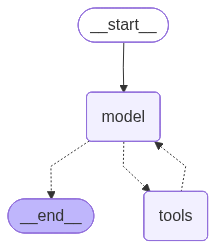

In [ ]:
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))